# Photovoice Pipeline (All Sections Included)
Compact version with essential code blocks.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, shutil, asyncio, matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ExifTags
import folium
from folium.plugins import MarkerCluster
from urllib.parse import urlparse, unquote
import pandas as pd
from collections import Counter
!pip install pyppeteer
from pyppeteer import launch

BASE='/content/drive/MyDrive/CONIFER'
INP=os.path.join(BASE,'input'); OUT=os.path.join(BASE,'output')
EXCEL=os.path.join(INP,'/content/drive/MyDrive/Zarco/CONIFER_Photo_Upload_Form2025-11-14_09_39_38.xlsx')
RAW=os.path.join(INP,'/content/drive/MyDrive/Zarco'); REN=os.path.join(INP,'renamed_photos')
POS=os.path.join(OUT,'positive_photos'); NEG=os.path.join(OUT,'negative_photos')
GR=os.path.join(OUT,'grids'); MAPS=os.path.join(OUT,'maps'); HIST=os.path.join(OUT,'histograms')
for p in [INP,OUT,REN,POS,NEG,GR,MAPS,HIST]: os.makedirs(p,exist_ok=True)

In [3]:

def clean(n):
    if pd.isna(n): return 'unnamed'
    n=str(n)
    for ch in r'\/:*?"<>|': n=n.replace(ch,'_')
    return n.strip()[:120]

def fname(v):
    if pd.isna(v): return None
    v=str(v).strip()
    if v.startswith('http'): return unquote(os.path.basename(urlparse(v).path))
    return os.path.basename(v)

def num(f):
    try:return int(f.split('_',1)[0])
    except:return 999999

def emo(f): return os.path.splitext(f)[0].split('_')[-1]

async def snap_async(h,j):
    b=await launch(args=['--no-sandbox']); p=await b.newPage()
    await p.goto(f'file://{h}',waitUntil='networkidle0')
    await p.setViewport({'width':1280,'height':900})
    t=j.replace('.jpg','_t.png')
    await p.screenshot({'path':t,'fullPage':True}); await b.close()
    Image.open(t).convert('RGB').save(j,'JPEG',quality=95); os.remove(t)

def snap(h,j):
    loop=asyncio.get_event_loop()
    if loop.is_running(): asyncio.ensure_future(snap_async(h,j))
    else: loop.run_until_complete(snap_async(h,j))


In [4]:

C_PN='Nome foto sensação positiva'; C_PF='Upload foto sensação positiva'
C_NN='Nome foto sensação negativa'; C_NF='Upload foto sensação negativa'
df=pd.read_excel(EXCEL)

for _,r in df.iterrows():
    npn=clean(r.get(C_PN,'')); op=fname(r.get(C_PF))
    if npn.startswith(('+_','-_')): npn=npn[2:]
    if op and os.path.exists(os.path.join(RAW,op)):
        ext=os.path.splitext(op)[1]
        shutil.copy2(os.path.join(RAW,op), os.path.join(REN,f'+_{npn}{ext}'))

    nnn=clean(r.get(C_NN,'')); on=fname(r.get(C_NF))
    if nnn.startswith(('+_','-_')): nnn=nnn[2:]
    if on and os.path.exists(os.path.join(RAW,on)):
        ext=os.path.splitext(on)[1]
        shutil.copy2(os.path.join(RAW,on), os.path.join(REN,f'-_{nnn}{ext}'))


In [5]:

photos=sorted([f for f in os.listdir(REN) if f.lower().endswith(('jpg','jpeg','png'))])
for i,f in enumerate(photos,1):
    src=os.path.join(REN,f); new=f"{i}_{f}"
    if f.startswith('+'): shutil.copy(src, os.path.join(POS,new))
    elif f.startswith('-'): shutil.copy(src, os.path.join(NEG,new))


In [6]:

def resize_keep_aspect(img, target):
    img.thumbnail(target, Image.LANCZOS)
    return img

def create_sentiment_grids(folder,out,label,grid=(5,2),cell=(200,200),font_size=12):
    fs=sorted([f for f in os.listdir(folder) if f.lower().endswith(('jpg','jpeg','png'))], key=num)
    fs=[os.path.join(folder,f) for f in fs]
    font=ImageFont.load_default(); g=0; cols,rows=grid
    for i in range(0,len(fs),cols*rows):
        sub=fs[i:i+cols*rows]
        W=cols*cell[0]; H=rows*(cell[1]+font_size+10)
        grid_img=Image.new('RGB',(W,H),'white'); dr=ImageDraw.Draw(grid_img)
        for idx,p in enumerate(sub):
            im=Image.open(p).convert('RGB')
            im=resize_keep_aspect(im,cell)
            xo=(cell[0]-im.size[0])//2; yo=(cell[1]-im.size[1])//2
            col=idx%cols; row=idx//cols
            x=col*cell[0]; y=row*(cell[1]+font_size+10)
            grid_img.paste(im,(x+xo,y+yo))
            dr.text((x+5,y+cell[1]+2),os.path.basename(p),fill='black',font=font)
        g+=1
        grid_img.save(os.path.join(out,f"{label}_grid_{g}.jpg"))

create_sentiment_grids(POS,GR,"positive")
create_sentiment_grids(NEG,GR,"negative")


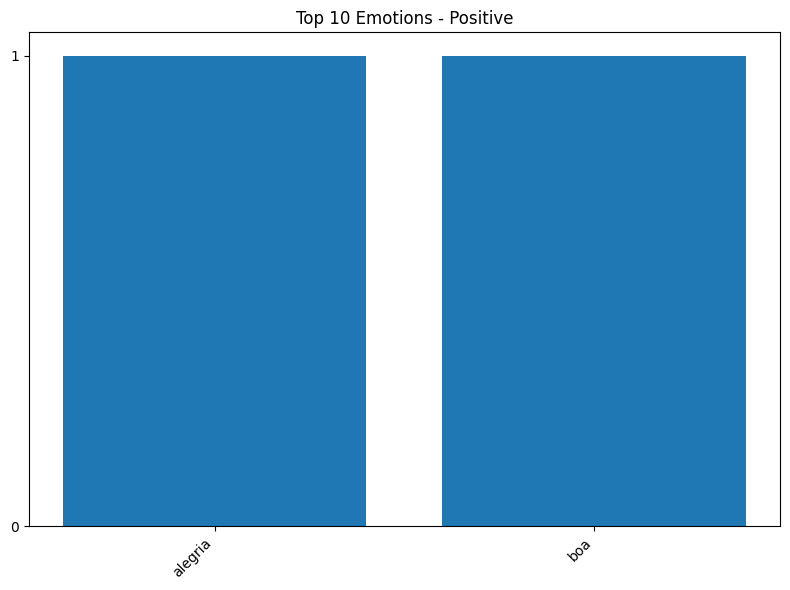

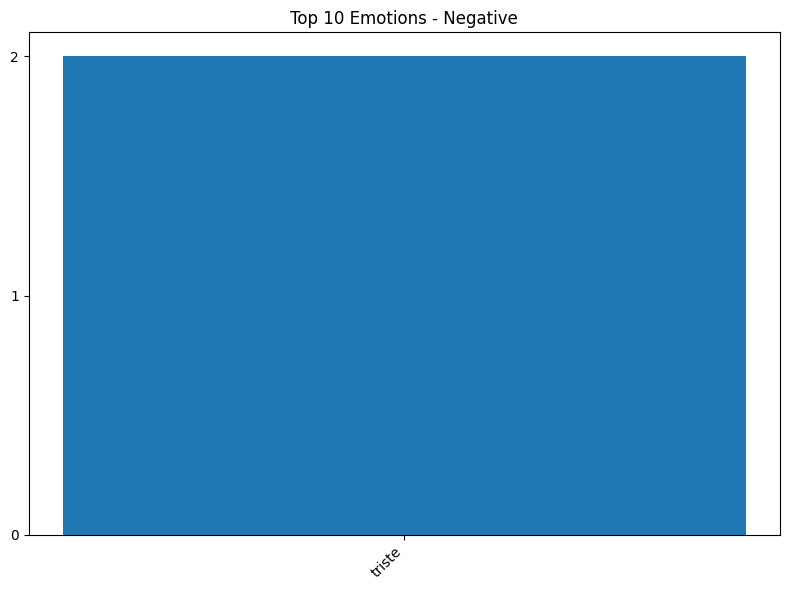

In [7]:

import matplotlib.ticker as ticker

def hist(folder,label):
    fs=[f for f in os.listdir(folder) if f.lower().endswith(('jpg','jpeg','png'))]
    em=[emo(f) for f in fs]; cnt=Counter(em).most_common(10)
    pd.DataFrame(cnt,columns=['emotion','count']).to_csv(os.path.join(HIST,f"{label}_emotion_counts.csv"),index=False)
    if not cnt: return
    labs=[x[0] for x in cnt]; vals=[x[1] for x in cnt]
    plt.figure(figsize=(8,6)); plt.bar(labs,vals)
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xticks(rotation=45,ha='right'); plt.title(f"Top 10 Emotions - {label.capitalize()}")
    plt.tight_layout()
    plt.savefig(os.path.join(HIST,f"{label}_emotions_histogram.jpg"),dpi=100); plt.show()

hist(POS,'positive'); hist(NEG,'negative')


In [8]:

def add_header(m,title):
    m.get_root().html.add_child(folium.Element(f'<h2 style="text-align:center;margin:10px 0">{title}</h2>'))

def exif(img):
    try:
        info=img._getexif(); d={}
        if info:
            for t,v in info.items():
                n=ExifTags.TAGS.get(t,t)
                if n=='GPSInfo':
                    gps={ExifTags.GPSTAGS.get(k,k):v[k] for k in v}
                    d['GPSInfo']=gps
                else:d[n]=v
        return d
    except:return {}

def deg(v):
    d,m,s=v; return d[0]/d[1]+(m[0]/m[1])/60+(s[0]/s[1])/3600

def latlon(e):
    g=e.get('GPSInfo')
    if not g:return None,None
    try:
        la=deg(g['GPSLatitude']);
        if g.get('GPSLatitudeRef')!='N': la=-la
        lo=deg(g['GPSLongitude'])
        if g.get('GPSLongitudeRef')!='E': lo=-lo
        return la,lo
    except:return None,None

def mkmap(folders,name,title):
    m=folium.Map(location=[41.18,-8.69],zoom_start=13)
    add_header(m,title)
    cl=MarkerCluster().add_to(m)
    data=[]
    for fo in folders:
        sent=os.path.basename(fo)
        for f in os.listdir(fo):
            if not f.lower().endswith(('jpg','jpeg','png')): continue
            p=os.path.join(fo,f); e=exif(Image.open(p)); la,lo=latlon(e)
            if la:
                data.append({'filename':f,'latitude':la,'longitude':lo,'sentiment':sent})
                folium.Marker([la,lo],popup=f).add_to(cl)
    df=pd.DataFrame(data)
    if not df.empty:
        df=df.sort_values(df['filename'].apply(num))
        df.to_csv(os.path.join(MAPS,f"{name}_metadata.csv"),index=False)
        df.to_excel(os.path.join(MAPS,f"{name}_metadata.xlsx"),index=False)
    html=os.path.join(MAPS,f"{name}.html"); m.save(html)
    snap(html, os.path.join(MAPS,f"{name}.jpg"))
    display(m)

mkmap([POS,NEG],"combined_map","Combined Map")
mkmap([POS],"positive_map","Positive Map")
mkmap([NEG],"negative_map","Negative Map")
